# edit distance dans corss vlaide ciuster

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10620\1957931760.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 99529
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10620\1957931760.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 95.00%
Test sur sujet sorti : 2
Précision split : 90.00%
Test sur sujet sorti : 3
Précision split : 98.00%
Test sur sujet sorti : 4
Précision split : 99.00%
Test sur sujet sorti : 5
Précision split : 90.00%
Test sur sujet sorti : 6
Précision split : 80.00%
Test sur sujet sorti : 7
Précision split : 89.00%
Test sur sujet sorti : 8
Précision split : 97.00%
Test sur sujet sorti : 9
Précision split : 96.00%
Test sur sujet sorti : 10
Précision split : 98.00%

=== EXACTITUDE GLOBALE : 93.20% ===


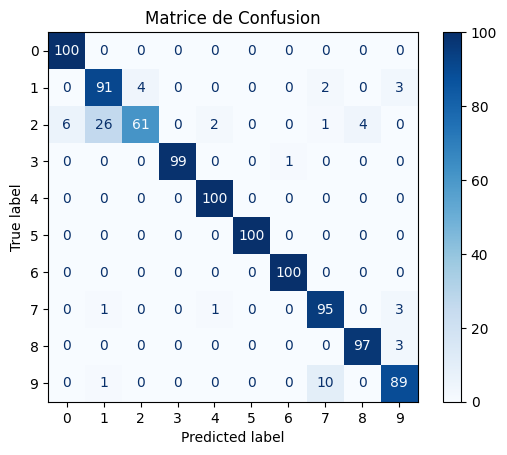

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()

testmodel(df100)

# lcss cluser 20 knn 3 cluseter dedans

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17644\1356518853.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 99529
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17644\1356518853.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 99.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 88.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 98.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 98.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 92.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 76.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 89.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 97.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 95.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 95.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 92.70% ===


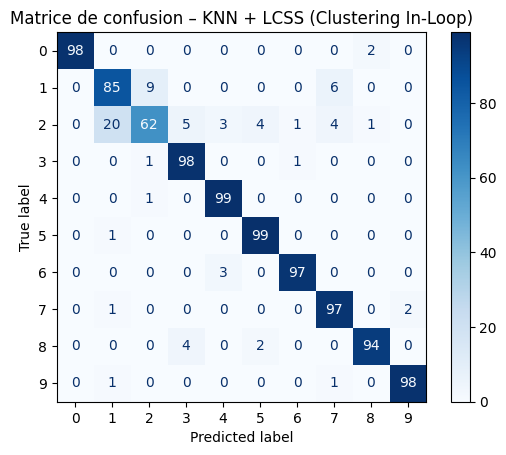

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)



def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        # Séparation User-Out
        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

# transformer

--- 1. Début du Chargement du Domaine 3 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé
Nombre total d'observations chargées : 99529


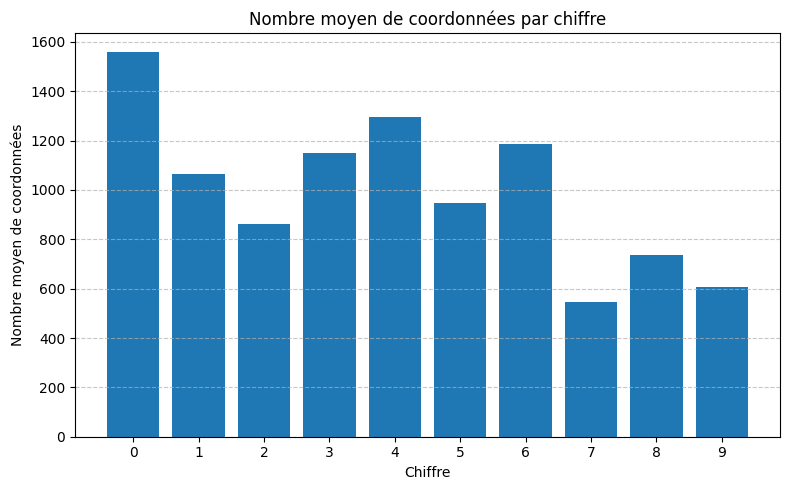

Chiffre 0 : 7534.30 s
Chiffre 1 : 5800.70 s
Chiffre 2 : 4499.00 s
Chiffre 3 : 7059.90 s
Chiffre 4 : 7407.10 s
Chiffre 5 : 4318.60 s
Chiffre 6 : 5602.90 s
Chiffre 7 : 2794.70 s
Chiffre 8 : 4108.20 s
Chiffre 9 : 2912.20 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17976\3730711776.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.0989 - loss: 2.4177
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.6056 - loss: 1.1200
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9278 - loss: 0.2293
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.9489 - loss: 0.1548
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9400 - loss: 0.2008
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.9789 - loss: 0.0858
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.9800 - loss: 0.0692
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9900 - loss: 0.0365
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9978 - loss: 0.0118
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step - accuracy: 1.0000 - loss: 0.0045
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 12/50
29/29 ━━

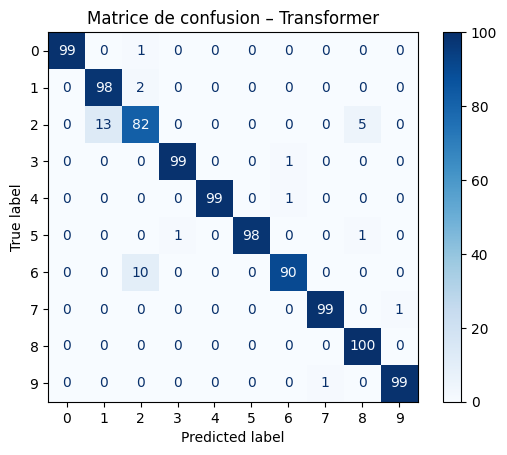

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"
DOMAIN_ID = 3


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")




def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=30, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()


test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

#lstm

--- 1. Début du Chargement du Domaine 3 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé
✅ Nombre total d'observations chargées : 99529

--- 2. Analyse Exploratoire ---


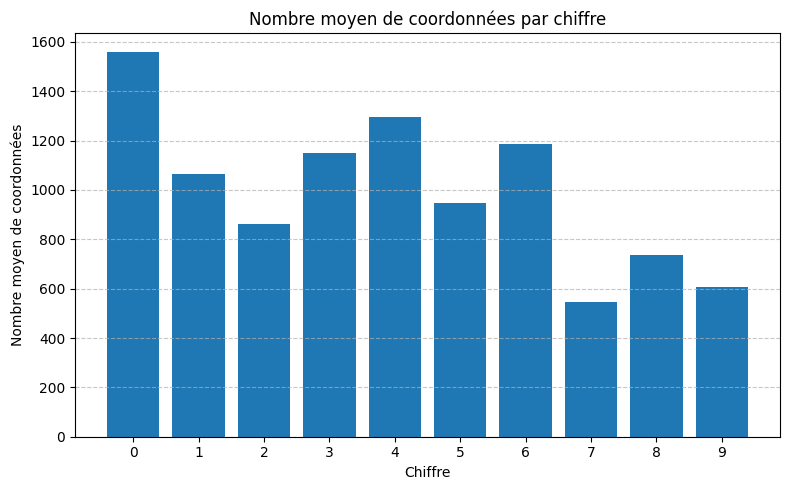

Chiffre 0 : 7534.30 s
Chiffre 1 : 5800.70 s
Chiffre 2 : 4499.00 s
Chiffre 3 : 7059.90 s
Chiffre 4 : 7407.10 s
Chiffre 5 : 4318.60 s
Chiffre 6 : 5602.90 s
Chiffre 7 : 2794.70 s
Chiffre 8 : 4108.20 s
Chiffre 9 : 2912.20 s

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_21324\2725923359.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 95.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 100.00%

--- Test subject OUT : 9 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 94.00%

--- Test subject OUT : 10 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 94.00%

Exactitude globale LSTM : 94.00%


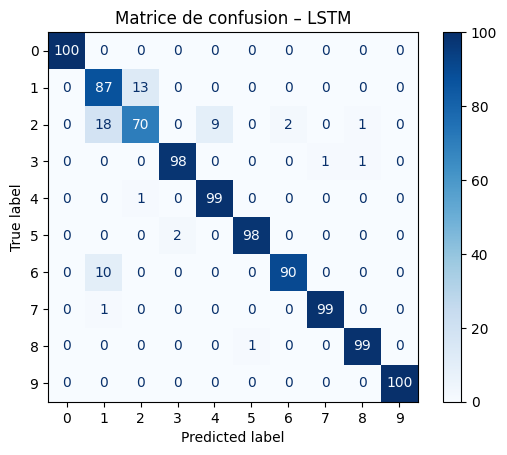

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"
DOMAIN_ID = 3

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except (FileNotFoundError, Exception):
                continue


if not df_list:
    raise ValueError(" Aucun fichier n'a été chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Nombre total d'observations chargées : {len(df)}")



print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)



def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test



def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



def test_lstm_user_independent(df_data, loop_range=10, epochs=50, batch_size=32):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)


        all_labels = np.unique(df_data['gesture'])
        num_classes = int(max(all_labels) + 1)

        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)


        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)


        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale LSTM : {final_acc:.2%}")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – LSTM")
    plt.show()


test_lstm_user_independent(df100)

#dtw

--- Début du Chargement ---
✅ Données chargées : 99529 lignes.


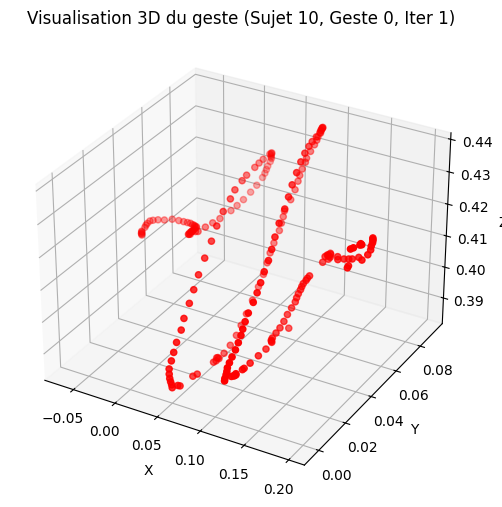


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


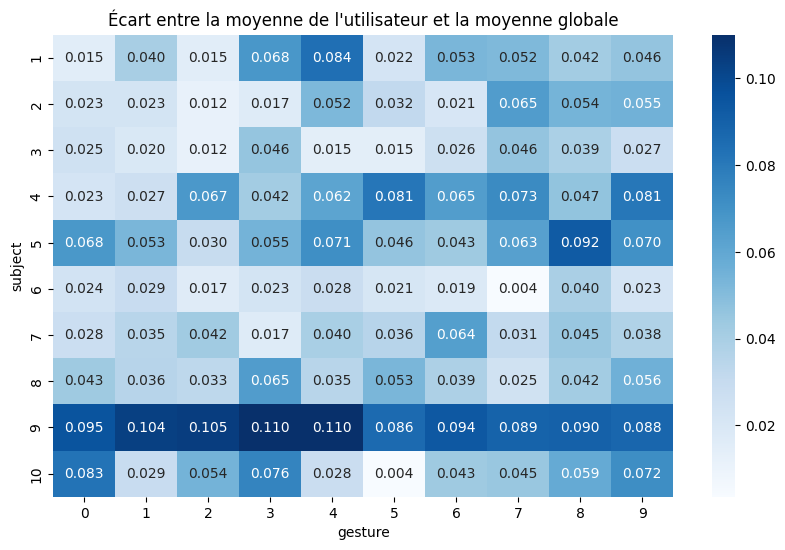

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10748\1713659362.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 98.00%

--- Test Split OUT : 2 ---
Précision split 2 : 94.00%

--- Test Split OUT : 3 ---
Précision split 3 : 100.00%

--- Test Split OUT : 4 ---
Précision split 4 : 100.00%

--- Test Split OUT : 5 ---
Précision split 5 : 96.00%

--- Test Split OUT : 6 ---
Précision split 6 : 86.00%

--- Test Split OUT : 7 ---
Précision split 7 : 95.00%

--- Test Split OUT : 8 ---
Précision split 8 : 98.00%

--- Test Split OUT : 9 ---
Précision split 9 : 100.00%

--- Test Split OUT : 10 ---
Précision split 10 : 99.00%

✅ Précision GLOBALE : 96.60%


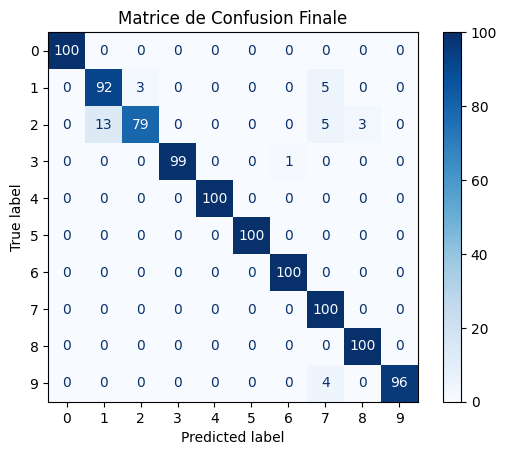

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("❌ Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\n Précision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()


testmodel(dict_creation_userout, df100, loop_range=10, k=3)

## partie 2

# lcss cluster 40 knn 3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")


for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=40):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/337950268.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/337950268.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 56.67%
Précision Sujet 7 : 86.67%
Précision Sujet 8 : 92.22%
Précision Sujet 9 : 94.44%
Précision Sujet 10 : 92.22%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 84.44% ===


## lcss cluster 40 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/3175058310.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/3175058310.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 93.33%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 77.78%
Précision Sujet 5 : 91.11%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 85.83% ===


## lcss cluster 5 knn 3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2929626569.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2929626569.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 91.11% ===


## lcs cluster 20 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1999155141.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1999155141.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 64.44%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 93.33%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.22% ===


## lcss 20 knn 3 test 4 et train 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1057662553.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1057662553.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 97.78%
Précision Sujet 2 : 82.22%
Précision Sujet 4 : 81.11%
Précision Sujet 5 : 95.56%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 89.17% ===


## lcss 20 knnn 3  test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/255378353.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/255378353.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 97.78% ===


## lccs cluster 50 knn3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=50):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3909215852.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3909215852.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 90.00%
Précision Sujet 10 : 90.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 87.33% ===


## lcss 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3865242021.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3865242021.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 92.22%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 77.78%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 85.28% ===


## lcss knn 3 cluster 50 test ur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3770817047.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3770817047.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 100.00% ===


## lcss cluster 20 knnn 5 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=5, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2084116074.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2084116074.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 67.78%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.67% ===


## lcss cluster 20 knn 5 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2828270476.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2828270476.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 96.67%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 80.00%
Précision Sujet 5 : 95.56%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 88.33% ===


# lcss cluseter 20 knn 5 test sujrt 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/909912744.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/909912744.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 98.89% ===


# lcsss cluster 20 knn7 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=7, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1652316991.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1652316991.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 66.67%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 92.22%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.44% ===


# lcss cluster 20 knn 7 trzine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1510633543.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1510633543.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 95.56%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 78.89%
Précision Sujet 5 : 94.44%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 87.50% ===


# lcss 20 knn 7 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/716571735.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/716571735.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 98.89% ===


# edity cluster 40 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/2940252810.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/2940252810.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 72.22%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 100.00%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 93.33%

=== EXACTITUDE GLOBALE : 90.00% ===


# edit cluster 40 knn 3 train5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/1212773953.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19462/1212773953.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 96.67%
Précision Sujet 2 : 80.00%
Précision Sujet 4 : 81.11%
Précision Sujet 5 : 87.78%

=== EXACTITUDE GLOBALE : 86.39% ===


# edit cluset 5 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=5):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/678840620.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/678840620.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 97.78% ===


# edit cluster 20 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3412343736.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3412343736.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 81.11%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 90.00%

=== EXACTITUDE GLOBALE : 90.89% ===


# edit cluster 20 knnn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3839389818.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3839389818.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 97.78%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 83.33%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 88.61% ===


# eit dist cluser 20 knnn 3 tets sur dujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2033278048.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2033278048.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# edit cluster 50 knn 3 test 5 train 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/12151476.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/12151476.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 75.56%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 94.44%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE : 88.67% ===


# edit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3116748457.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3116748457.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 94.44%
Précision Sujet 2 : 80.00%
Précision Sujet 4 : 80.00%
Précision Sujet 5 : 87.78%

=== EXACTITUDE GLOBALE : 85.56% ===


# edit cluster 50 knn 3 sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2105981361.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2105981361.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 100.00% ===


# edit clusetr 20 knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/3767623598.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/3767623598.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 81.11%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE : 90.67% ===


# edit clusetr 20 knn 5 train 5 tet 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1530094638.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1530094638.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 96.67%
Précision Sujet 2 : 84.44%
Précision Sujet 4 : 81.11%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 88.06% ===


# edit cluster 20 knn 5 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1735383610.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1735383610.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# edit cluster 20 knn 7 train 4 teste 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1453896431.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1453896431.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 80.00%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE : 90.44% ===


# edit cluster 20 knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/40327524.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/40327524.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 93.33%
Précision Sujet 2 : 84.44%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 86.11% ===


# edit clusterb 20 knn 7 sujet 3 testy

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1777636687.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1777636687.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# test

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/2273333909.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/2273333909.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 100.00% ===

Affichage du graphique 3D...


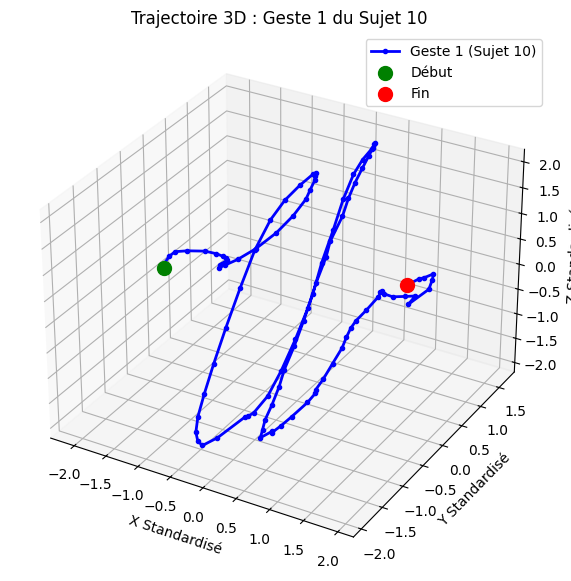

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D

# ===========================================================
# 1. CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN4 (adapté à votre structure)
DOMAIN_FOLDER =os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes pour ignorer les headers inutiles
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : séparation des colonnes et retrait des guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 2. FONCTIONS DE TRAITEMENT (Symbolisation & Distance)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)
    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 3. TEST FINAL & VISUALISATION 3D
# ===========================================================

def plot_specific_gesture(df_input, subject_id, gesture_id, iter_id=1):
    # Filtrage pour obtenir le geste spécifique
    sample = df_input[(df_input['subject'] == subject_id) &
                      (df_input['gesture'] == gesture_id) &
                      (df_input['iter'] == iter_id)]

    if sample.empty:
        print(f"⚠️ Aucune donnée trouvée pour Sujet {subject_id}, Geste {gesture_id}")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Tracé de la trajectoire
    ax.plot(sample['x_std'], sample['y_std'], sample['z_std'],
            label=f'Geste {gesture_id} (Sujet {subject_id})',
            color='blue', linewidth=2, marker='o', markersize=3)

    # Points Début/Fin
    ax.scatter(sample['x_std'].iloc[0], sample['y_std'].iloc[0], sample['z_std'].iloc[0], color='green', s=100, label='Début')
    ax.scatter(sample['x_std'].iloc[-1], sample['y_std'].iloc[-1], sample['z_std'].iloc[-1], color='red', s=100, label='Fin')

    ax.set_title(f"Trajectoire 3D : Geste {gesture_id} du Sujet {subject_id}")
    ax.set_xlabel('X Standardisé')
    ax.set_ylabel('Y Standardisé')
    ax.set_zlabel('Z Standardisé')
    ax.legend()
    plt.show()

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# --- LANCEMENT ---
if not df100.empty:
    # 1. Analyse statistique
    run_leave_subject_3_out(df100)

    # 2. Visualisation demandée
    print("\nAffichage du graphique 3D...")
    plot_specific_gesture(df100, subject_id=10, gesture_id=1, iter_id=1)

# lstm 64 64 32 tréin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_16519/2534863899.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3179 - loss: 2.1142 - val_accuracy: 0.0000e+00 - val_loss: 2.4408
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.5123 - loss: 1.6573 - val_accuracy: 0.0000e+00 - val_loss: 2.6991
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6605 - loss: 1.1995 - val_accuracy: 0.0000e+00 - val_loss: 2.9753
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7593 - loss: 0.8633 - val_accuracy: 0.0000e+00 - val_loss: 3.2640
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8117 - loss: 0.6237 - val_accuracy: 0.0000e+00 - val_loss: 2.3647
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9074 - loss: 0.4559 - val_accuracy: 0.0000e+00 - val_loss: 2.5000
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9105 - loss: 0.3418 - val_accuracy: 0.0000e+00 - val_loss: 2.5853
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9136 - loss: 0.2680 - val_a

# lstm 64 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_16519/1818936154.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.4272 - loss: 2.0890 - val_accuracy: 0.0000e+00 - val_loss: 2.4870
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5333 - loss: 1.4151 - val_accuracy: 0.0000e+00 - val_loss: 2.8662
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7358 - loss: 0.8496 - val_accuracy: 0.0000e+00 - val_loss: 3.8546
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8988 - loss: 0.5091 - val_accuracy: 0.0000e+00 - val_loss: 4.1510
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.9407 - loss: 0.3196 - val_accuracy: 0.0000e+00 - val_loss: 3.9758
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9333 - loss: 0.2234 - val_accuracy: 0.0000e+00 - val_loss: 2.9252
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9457 - loss: 0.1754 - val_accuracy: 0.0000e+00 - val_loss: 3.3190
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9506 - loss: 0.1441 - val_

# lstm 128 64 32 trin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_16519/1298430518.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.4753 - loss: 1.9106 - val_accuracy: 0.0000e+00 - val_loss: 3.1556
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - accuracy: 0.7006 - loss: 1.0481 - val_accuracy: 0.0000e+00 - val_loss: 3.6394
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.8272 - loss: 0.6132 - val_accuracy: 0.0000e+00 - val_loss: 3.5638
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.8519 - loss: 0.3993 - val_accuracy: 0.0000e+00 - val_loss: 2.7291
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.8889 - loss: 0.3034 - val_accuracy: 0.0000e+00 - val_loss: 1.8563
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.9105 - loss: 0.2456 - val_accuracy: 0.0000e+00 - val_loss: 1.7623
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.9228 - loss: 0.1958 - val_accuracy: 0.4167 - val_loss: 1.0137
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.9414 - loss: 0.1744 - val

# lstm 128 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_16519/2782178349.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.4469 - loss: 1.8010 - val_accuracy: 0.0000e+00 - val_loss: 2.3477
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.7309 - loss: 0.8722 - val_accuracy: 0.0000e+00 - val_loss: 3.9417
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.9012 - loss: 0.3993 - val_accuracy: 0.0000e+00 - val_loss: 3.3589
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.9284 - loss: 0.2232 - val_accuracy: 0.0000e+00 - val_loss: 2.9567
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.9383 - loss: 0.1656 - val_accuracy: 0.0000e+00 - val_loss: 2.9780
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.9531 - loss: 0.1404 - val_accuracy: 0.0222 - val_loss: 3.7569
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.9556 - loss: 0.1305 - val_accuracy: 0.1556 - val_loss: 3.2763
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.9037 - loss: 0.2919 - val_acc

# lstm 256 64 32 tain 4 tets 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_16519/2223121396.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 666ms/step - accuracy: 0.4691 - loss: 1.7589 - val_accuracy: 0.0000e+00 - val_loss: 2.8766
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 755ms/step - accuracy: 0.7469 - loss: 0.8725 - val_accuracy: 0.0000e+00 - val_loss: 2.3535
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 621ms/step - accuracy: 0.7963 - loss: 0.6380 - val_accuracy: 0.0000e+00 - val_loss: 2.7476
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 748ms/step - accuracy: 0.8025 - loss: 0.5912 - val_accuracy: 0.0000e+00 - val_loss: 3.3672
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 755ms/step - accuracy: 0.8611 - loss: 0.4184 - val_accuracy: 0.0000e+00 - val_loss: 2.4500
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 628ms/step - accuracy: 0.8920 - loss: 0.3253 - val_accuracy: 0.0000e+00 - val_loss: 3.0231
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 624ms/step - accuracy: 0.9290 - loss: 0.2430 - val_accuracy: 0.0000e+00 - val_loss: 2.0096
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 755ms/step - accuracy: 0.9074 - loss: 0.281

# lstm 256 64 32 teain 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS =  [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_16519/3418351003.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 785ms/step - accuracy: 0.5580 - loss: 1.5237 - val_accuracy: 0.0000e+00 - val_loss: 2.7412
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 727ms/step - accuracy: 0.8296 - loss: 0.5255 - val_accuracy: 0.0000e+00 - val_loss: 3.1428
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 634ms/step - accuracy: 0.8988 - loss: 0.3237 - val_accuracy: 0.0000e+00 - val_loss: 2.4927
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 743ms/step - accuracy: 0.9160 - loss: 0.2474 - val_accuracy: 0.0444 - val_loss: 1.8801
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 729ms/step - accuracy: 0.9284 - loss: 0.2107 - val_accuracy: 0.4444 - val_loss: 1.2480
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 672ms/step - accuracy: 0.9679 - loss: 0.1323 - val_accuracy: 0.8222 - val_loss: 0.5854
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 640ms/step - accuracy: 0.9630 - loss: 0.1139 - val_accuracy: 0.8667 - val_loss: 0.4723
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 731ms/step - accuracy: 0.9309 - loss: 0.2521 - val_accurac

# lstm 256 dense 32 32 train n4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/3750189819.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 899ms/step - accuracy: 0.4074 - loss: 1.8066 - val_accuracy: 0.0000e+00 - val_loss: 4.1278
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 805ms/step - accuracy: 0.6636 - loss: 1.0857 - val_accuracy: 0.0000e+00 - val_loss: 4.0529
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 719ms/step - accuracy: 0.7716 - loss: 0.7651 - val_accuracy: 0.0000e+00 - val_loss: 3.3320
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 855ms/step - accuracy: 0.8302 - loss: 0.6286 - val_accuracy: 0.0000e+00 - val_loss: 1.9489
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 989ms/step - accuracy: 0.8333 - loss: 0.5659 - val_accuracy: 0.0000e+00 - val_loss: 1.7108
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 729ms/step - accuracy: 0.8580 - loss: 0.4329 - val_accuracy: 0.0278 - val_loss: 2.3390
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 854ms/step - accuracy: 0.8796 - loss: 0.3366 - val_accuracy: 0.1389 - val_loss: 1.6495
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 836ms/step - accuracy: 0.8549 - loss: 0.4063 - val_

# lstm 256 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =    [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/3604324881.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4593 - loss: 1.7656 - val_accuracy: 0.0000e+00 - val_loss: 3.0014
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 986ms/step - accuracy: 0.7086 - loss: 0.8897 - val_accuracy: 0.0000e+00 - val_loss: 2.4218
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 957ms/step - accuracy: 0.8741 - loss: 0.4562 - val_accuracy: 0.0000e+00 - val_loss: 2.3426
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 961ms/step - accuracy: 0.9012 - loss: 0.3534 - val_accuracy: 0.0000e+00 - val_loss: 1.6493
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 946ms/step - accuracy: 0.9111 - loss: 0.2755 - val_accuracy: 0.0444 - val_loss: 1.2545
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 940ms/step - accuracy: 0.9358 - loss: 0.1904 - val_accuracy: 0.6000 - val_loss: 1.1336
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 983ms/step - accuracy: 0.9432 - loss: 0.1794 - val_accuracy: 0.9111 - val_loss: 0.6030
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 830ms/step - accuracy: 0.9432 - loss: 0.14

# lstm 256 16 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/3459931425.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3673 - loss: 1.8521 - val_accuracy: 0.0000e+00 - val_loss: 6.1897
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 814ms/step - accuracy: 0.5679 - loss: 1.2915 - val_accuracy: 0.0000e+00 - val_loss: 4.1508
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 969ms/step - accuracy: 0.6821 - loss: 0.9298 - val_accuracy: 0.0000e+00 - val_loss: 4.3499
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 961ms/step - accuracy: 0.7099 - loss: 0.8323 - val_accuracy: 0.0000e+00 - val_loss: 3.6506
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 962ms/step - accuracy: 0.7901 - loss: 0.7966 - val_accuracy: 0.0000e+00 - val_loss: 3.4955
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 912ms/step - accuracy: 0.7716 - loss: 0.6631 - val_accuracy: 0.0000e+00 - val_loss: 3.5801
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8148 - loss: 0.5627 - val_accuracy: 0.0000e+00 - val_loss: 2.8949
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 885ms/step - accuracy: 0.8395 - lo

# lstm 256 16 32 treéain 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =    [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/1298892538.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4148 - loss: 1.6645 - val_accuracy: 0.0000e+00 - val_loss: 4.7467
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 967ms/step - accuracy: 0.6840 - loss: 0.9961 - val_accuracy: 0.0000e+00 - val_loss: 5.4494
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 962ms/step - accuracy: 0.7753 - loss: 0.6994 - val_accuracy: 0.0000e+00 - val_loss: 5.7141
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8914 - loss: 0.4339 - val_accuracy: 0.0000e+00 - val_loss: 3.1753
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 995ms/step - accuracy: 0.8963 - loss: 0.3368 - val_accuracy: 0.0889 - val_loss: 3.8893
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8988 - loss: 0.2858 - val_accuracy: 0.1556 - val_loss: 3.5059
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 980ms/step - accuracy: 0.8963 - loss: 0.3202 - val_accuracy: 0.0000e+00 - val_loss: 4.1327
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 972ms/step - accuracy: 0.8667 - loss: 0.5093

# lstm 256 64 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =     [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/3855752591.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4259 - loss: 2.0176 - val_accuracy: 0.0000e+00 - val_loss: 3.9829
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6235 - loss: 1.2533 - val_accuracy: 0.0000e+00 - val_loss: 4.1284
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7315 - loss: 0.9244 - val_accuracy: 0.0000e+00 - val_loss: 3.0661
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7963 - loss: 0.6867 - val_accuracy: 0.0000e+00 - val_loss: 3.8544
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8580 - loss: 0.5263 - val_accuracy: 0.0000e+00 - val_loss: 2.3450
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8549 - loss: 0.4474 - val_accuracy: 0.0000e+00 - val_loss: 2.0348
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8642 - loss: 0.3885 - val_accuracy: 0.0000e+00 - val_loss: 3.0107
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8704 - loss: 0.3240 - val_accuracy: 0.0278 - va

# lstm 256 64 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =       [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/436330355.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4370 - loss: 1.9245 - val_accuracy: 0.0000e+00 - val_loss: 3.3140
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7333 - loss: 0.8596 - val_accuracy: 0.0000e+00 - val_loss: 4.2430
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8296 - loss: 0.5505 - val_accuracy: 0.0000e+00 - val_loss: 4.4344
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8938 - loss: 0.3329 - val_accuracy: 0.0000e+00 - val_loss: 5.3168
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9284 - loss: 0.2577 - val_accuracy: 0.0000e+00 - val_loss: 3.2398
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9062 - loss: 0.2678 - val_accuracy: 0.0000e+00 - val_loss: 3.9820
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9259 - loss: 0.2745 - val_accuracy: 0.0000e+00 - val_loss: 2.4525
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9383 - loss: 0.2042 - val_accuracy: 0.0000e+00 - val_loss

# lstm 256 64 16 trai 4 tes 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =     [1, 2, 4, 5]
TEST_SUBJECTS =[6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/3990381407.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 619ms/step - accuracy: 0.5309 - loss: 1.3968 - val_accuracy: 0.0000e+00 - val_loss: 5.1607
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 592ms/step - accuracy: 0.7593 - loss: 0.6851 - val_accuracy: 0.0000e+00 - val_loss: 3.9082
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.7932 - loss: 0.6189 - val_accuracy: 0.0000e+00 - val_loss: 2.7686
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.8549 - loss: 0.4320 - val_accuracy: 0.0000e+00 - val_loss: 3.7476
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 589ms/step - accuracy: 0.8858 - loss: 0.2996 - val_accuracy: 0.4167 - val_loss: 1.5301
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 534ms/step - accuracy: 0.9136 - loss: 0.2275 - val_accuracy: 0.3889 - val_loss: 1.4682
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 587ms/step - accuracy: 0.9290 - loss: 0.1840 - val_accuracy: 0.3611 - val_loss: 2.2808
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 603ms/step - accuracy: 0.9167 - loss: 0.2676 - val

# lstm 256 64 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS =[1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_346/2182652576.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 719ms/step - accuracy: 0.6765 - loss: 1.1409 - val_accuracy: 0.0000e+00 - val_loss: 5.1593
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 714ms/step - accuracy: 0.8765 - loss: 0.3761 - val_accuracy: 0.0000e+00 - val_loss: 4.5583
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 724ms/step - accuracy: 0.8988 - loss: 0.2940 - val_accuracy: 0.0444 - val_loss: 4.2185
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 674ms/step - accuracy: 0.9235 - loss: 0.2787 - val_accuracy: 0.0000e+00 - val_loss: 3.3129
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 734ms/step - accuracy: 0.9235 - loss: 0.2435 - val_accuracy: 0.0222 - val_loss: 3.0292
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 657ms/step - accuracy: 0.9556 - loss: 0.1460 - val_accuracy: 0.1111 - val_loss: 3.2541
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 685ms/step - accuracy: 0.9432 - loss: 0.1429 - val_accuracy: 0.1111 - val_loss: 4.3167
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 693ms/step - accuracy: 0.8593 - loss: 0.467

# trandsofmer

# TR 64 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/982966801.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1204 - loss: 2.3593 - val_accuracy: 0.0000e+00 - val_loss: 3.9284
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1358 - loss: 2.2327 - val_accuracy: 0.0000e+00 - val_loss: 4.2868
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1852 - loss: 2.1536 - val_accuracy: 0.0000e+00 - val_loss: 4.7628
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4506 - loss: 1.6310 - val_accuracy: 0.0000e+00 - val_loss: 2.8849
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8272 - loss: 0.6019 - val_accuracy: 0.1389 - val_loss: 1.5563
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9259 - loss: 0.2447 - val_accuracy: 0.7500 - val_loss: 0.7260
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9537 - loss: 0.1472 - val_accuracy: 0.3889 - val_loss: 1.8501
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.

# TR 64 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/3740445314.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.1136 - loss: 2.3324 - val_accuracy: 0.0000e+00 - val_loss: 4.8781
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2099 - loss: 2.0833 - val_accuracy: 0.0000e+00 - val_loss: 3.9086
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7802 - loss: 0.8656 - val_accuracy: 0.0000e+00 - val_loss: 4.4305
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9704 - loss: 0.1708 - val_accuracy: 0.6889 - val_loss: 0.8169
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9877 - loss: 0.0565 - val_accuracy: 0.9111 - val_loss: 0.2532
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9827 - loss: 0.0655 - val_accuracy: 1.0000 - val_loss: 0.0639
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9975 - loss: 0.0157 - val_accuracy: 0.9556 - val_loss: 0.0876
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9951

# tr 128 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/3741695221.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1235 - loss: 2.4159 - val_accuracy: 0.0000e+00 - val_loss: 3.6560
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1481 - loss: 2.1649 - val_accuracy: 0.0000e+00 - val_loss: 4.3169
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1728 - loss: 2.1770 - val_accuracy: 0.0000e+00 - val_loss: 4.1124
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4105 - loss: 1.6416 - val_accuracy: 0.0000e+00 - val_loss: 5.5385
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7963 - loss: 0.6979 - val_accuracy: 0.0000e+00 - val_loss: 3.3657
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9074 - loss: 0.2881 - val_accuracy: 0.2500 - val_loss: 2.3073
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9444 - loss: 0.2238 - val_accuracy: 0.5556 - val_loss: 1.8162
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy

# tr 128 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/4033760874.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.1210 - loss: 2.4110 - val_accuracy: 0.0000e+00 - val_loss: 3.2713
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1111 - loss: 2.2186 - val_accuracy: 0.0000e+00 - val_loss: 3.9719
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.3185 - loss: 1.9019 - val_accuracy: 0.0000e+00 - val_loss: 3.8218
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8790 - loss: 0.5430 - val_accuracy: 0.0000e+00 - val_loss: 3.6934
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9704 - loss: 0.1099 - val_accuracy: 0.9111 - val_loss: 0.5249
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9852 - loss: 0.0516 - val_accuracy: 0.9333 - val_loss: 0.1459
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9827 - loss: 0.0825 - val_accuracy: 0.8889 - val_loss: 0.3388
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.

# tr 256 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/4079460721.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1481 - loss: 2.3860 - val_accuracy: 0.0000e+00 - val_loss: 3.7270
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1296 - loss: 2.2341 - val_accuracy: 0.0000e+00 - val_loss: 4.4891
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1636 - loss: 2.1268 - val_accuracy: 0.0000e+00 - val_loss: 4.9124
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6481 - loss: 1.1631 - val_accuracy: 0.0833 - val_loss: 2.1463
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8704 - loss: 0.4322 - val_accuracy: 0.0278 - val_loss: 2.1042
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9475 - loss: 0.1854 - val_accuracy: 0.9722 - val_loss: 0.1421
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9506 - loss: 0.1536 - val_accuracy: 1.0000 - val_loss: 0.0808
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9198

# tr 256 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_14592/1487165094.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 933ms/step - accuracy: 0.1481 - loss: 2.2988 - val_accuracy: 0.0000e+00 - val_loss: 4.7738
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 890ms/step - accuracy: 0.1235 - loss: 2.2079 - val_accuracy: 0.0000e+00 - val_loss: 3.7694
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 874ms/step - accuracy: 0.1753 - loss: 2.0802 - val_accuracy: 0.0000e+00 - val_loss: 4.5719
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 871ms/step - accuracy: 0.7580 - loss: 0.8403 - val_accuracy: 0.0000e+00 - val_loss: 6.9832
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 907ms/step - accuracy: 0.9210 - loss: 0.2180 - val_accuracy: 0.5556 - val_loss: 1.0309
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 864ms/step - accuracy: 0.9753 - loss: 0.0839 - val_accuracy: 1.0000 - val_loss: 0.0468
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 856ms/step - accuracy: 0.9852 - loss: 0.0414 - val_accuracy: 0.9778 - val_loss: 0.0864
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 8

# transfo 256 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_346/3666056241.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1173 - loss: 2.3113 - val_accuracy: 0.0000e+00 - val_loss: 3.5152
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1512 - loss: 2.2048 - val_accuracy: 0.0000e+00 - val_loss: 4.1475
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1605 - loss: 2.1631 - val_accuracy: 0.0000e+00 - val_loss: 3.8238
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2006 - loss: 2.0487 - val_accuracy: 0.0000e+00 - val_loss: 3.2825
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4907 - loss: 1.3681 - val_accuracy: 0.0000e+00 - val_loss: 4.1021
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7963 - loss: 0.6392 - val_accuracy: 0.0278 - val_loss: 1.9749
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8920 - loss: 0.3925 - val_accuracy: 0.0278 - val_loss: 1.7236
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy

# transfo 256 64 32 trzin 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_346/1935409013.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1210 - loss: 2.3856 - val_accuracy: 0.0000e+00 - val_loss: 3.5688
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1556 - loss: 2.1995 - val_accuracy: 0.0000e+00 - val_loss: 3.3053
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1506 - loss: 2.1622 - val_accuracy: 0.0000e+00 - val_loss: 2.8728
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6272 - loss: 1.1867 - val_accuracy: 0.0000e+00 - val_loss: 3.3167
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8494 - loss: 0.4844 - val_accuracy: 0.0889 - val_loss: 1.9724
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9580 - loss: 0.2063 - val_accuracy: 0.4889 - val_loss: 1.1321
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9654 - loss: 0.1096 - val_accuracy: 0.7111 - val_loss: 0.7716
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.

# traqnfo 256 32 32 train 4 tes 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/1476351627.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.0957 - loss: 2.4053 - val_accuracy: 0.0000e+00 - val_loss: 2.9960
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1080 - loss: 2.2261 - val_accuracy: 0.0000e+00 - val_loss: 3.7308
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1265 - loss: 2.2212 - val_accuracy: 0.0000e+00 - val_loss: 3.3441
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 902ms/step - accuracy: 0.2222 - loss: 2.0849 - val_accuracy: 0.0000e+00 - val_loss: 5.2124
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5093 - loss: 1.4321 - val_accuracy: 0.0000e+00 - val_loss: 4.3247
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7469 - loss: 0.8290 - val_accuracy: 0.0000e+00 - val_loss: 2.8927
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8457 - loss: 0.4890 - val_accuracy: 0.1944 - val_loss: 2.4696
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - a

# transfo 256 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/3779997981.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.0988 - loss: 2.3790 - val_accuracy: 0.0000e+00 - val_loss: 2.3149
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1235 - loss: 2.2985 - val_accuracy: 0.0000e+00 - val_loss: 2.3295
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1235 - loss: 2.2952 - val_accuracy: 0.0000e+00 - val_loss: 2.3436
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1185 - loss: 2.2924 - val_accuracy: 0.0000e+00 - val_loss: 2.3577
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1136 - loss: 2.2896 - val_accuracy: 0.0000e+00 - val_loss: 2.3715
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1210 - loss: 2.2861 - val_accuracy: 0.0000e+00 - val_loss: 2.3854
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1235 - loss: 2.2831 - val_accuracy: 0.0000e+00 - val_loss: 2.3991
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - 

# transfo 256 128 16 train 4 test 5

> Ajouter une citation

> Ajouter une citation





In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_14592/3768317417.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 708ms/step - accuracy: 0.0926 - loss: 2.4018 - val_accuracy: 0.0000e+00 - val_loss: 3.7292
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 947ms/step - accuracy: 0.1142 - loss: 2.1882 - val_accuracy: 0.0000e+00 - val_loss: 4.3630
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 694ms/step - accuracy: 0.4537 - loss: 1.5356 - val_accuracy: 0.0000e+00 - val_loss: 3.3775
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 665ms/step - accuracy: 0.8765 - loss: 0.3703 - val_accuracy: 0.0000e+00 - val_loss: 2.8090
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 393ms/step - accuracy: 0.9136 - loss: 0.2845 - val_accuracy: 0.7778 - val_loss: 0.9396
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 0.9475 - loss: 0.1402 - val_accuracy: 1.0000 - val_loss: 0.1985
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - accuracy: 0.9537 - loss: 0.1522 - val_accuracy: 0.9167 - val_loss: 0.3335
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 419m

# tr 256 128 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_14592/2570463491.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 427ms/step - accuracy: 0.1012 - loss: 2.3559 - val_accuracy: 0.0000e+00 - val_loss: 4.1105
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step - accuracy: 0.1235 - loss: 2.2250 - val_accuracy: 0.0000e+00 - val_loss: 3.5588
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.7605 - loss: 0.8470 - val_accuracy: 0.0000e+00 - val_loss: 3.2786
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 404ms/step - accuracy: 0.9457 - loss: 0.1747 - val_accuracy: 0.2444 - val_loss: 1.0037
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.9877 - loss: 0.0618 - val_accuracy: 0.9778 - val_loss: 0.1373
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 371ms/step - accuracy: 0.9679 - loss: 0.0975 - val_accuracy: 0.7556 - val_loss: 0.6452
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.9753 - loss: 0.0947 - val_accuracy: 0.7333 - val_loss: 0.4491
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms

# tr 256 128 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_14592/2925450351.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1080 - loss: 2.5082 - val_accuracy: 0.0000e+00 - val_loss: 3.9596
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1636 - loss: 2.2617 - val_accuracy: 0.0000e+00 - val_loss: 3.6632
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1265 - loss: 2.2891 - val_accuracy: 0.0000e+00 - val_loss: 4.5974
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1790 - loss: 2.2007 - val_accuracy: 0.0000e+00 - val_loss: 4.3736
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2932 - loss: 1.9510 - val_accuracy: 0.0000e+00 - val_loss: 3.8737
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6204 - loss: 1.2577 - val_accuracy: 0.0000e+00 - val_loss: 4.1886
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7593 - loss: 0.7707 - val_accuracy: 0.0000e+00 - val_loss: 3.9186
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8580

# tr 256 128 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_14592/3015490772.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1235 - loss: 2.4211 - val_accuracy: 0.0000e+00 - val_loss: 3.4284
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1259 - loss: 2.2746 - val_accuracy: 0.0000e+00 - val_loss: 4.3542
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1383 - loss: 2.2269 - val_accuracy: 0.0000e+00 - val_loss: 4.2819
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1358 - loss: 2.1579 - val_accuracy: 0.0000e+00 - val_loss: 3.9398
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4123 - loss: 1.7056 - val_accuracy: 0.0000e+00 - val_loss: 3.1619
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7753 - loss: 0.8580 - val_accuracy: 0.0000e+00 - val_loss: 2.8857
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8790 - loss: 0.3403 - val_accuracy: 0.1111 - val_loss: 1.9492
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9531 - l

# dtw knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_1108/2441628181.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 87.78%
Résultat Sujet 7 : 88.89%
Résultat Sujet 8 : 98.89%
Résultat Sujet 9 : 97.78%
Résultat Sujet 10 : 88.89%
------------------------------
 PRÉCISION GLOBALE : 92.44%


# dtw knn 3 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS =  [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_1108/461667438.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 97.78%
Résultat Sujet 2 : 85.56%
Résultat Sujet 4 : 88.89%
Résultat Sujet 5 : 95.56%
------------------------------
 PRÉCISION GLOBALE : 91.94%


# dtw knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_1108/2922911763.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 86.67%
Résultat Sujet 7 : 88.89%
Résultat Sujet 8 : 98.89%
Résultat Sujet 9 : 97.78%
Résultat Sujet 10 : 88.89%
------------------------------
 PRÉCISION GLOBALE : 92.22%


# dtw knn 5 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS =  [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_1108/4111306807.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 97.78%
Résultat Sujet 2 : 85.56%
Résultat Sujet 4 : 88.89%
Résultat Sujet 5 : 95.56%
------------------------------
 PRÉCISION GLOBALE : 91.94%


# knn 7 train 4 tets 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_11178/3237074653.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 81.11%
Résultat Sujet 7 : 88.89%
Résultat Sujet 8 : 98.89%
Résultat Sujet 9 : 97.78%
Résultat Sujet 10 : 88.89%
------------------------------
 PRÉCISION GLOBALE : 91.11%


# dtw knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS =  [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")




# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_11178/3631465816.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 97.78%
Résultat Sujet 2 : 85.56%
Résultat Sujet 4 : 88.89%
Résultat Sujet 5 : 94.44%
------------------------------
 PRÉCISION GLOBALE : 91.67%


# dtaw final partie 2 knn 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
# On cherche le dossier qui contient les fichiers CSV pour éviter le problème d'accent
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On prend le premier dossier trouvé dans temp_data
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
    #print(f" Dossier détecté par le système : {DOMAIN_FOLDER}")
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé dans {DOMAIN_FOLDER}. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    ConfusionMatrixDisplay(confusion_matrix(total_true, total_pred)).plot(cmap="Blues")
    plt.show()

testmodel(df100, loop_range=10, k=3)

 Décompression terminée !
--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_1424/238721694.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

# tes

 Décompression terminée !
--- Début du Chargement ---


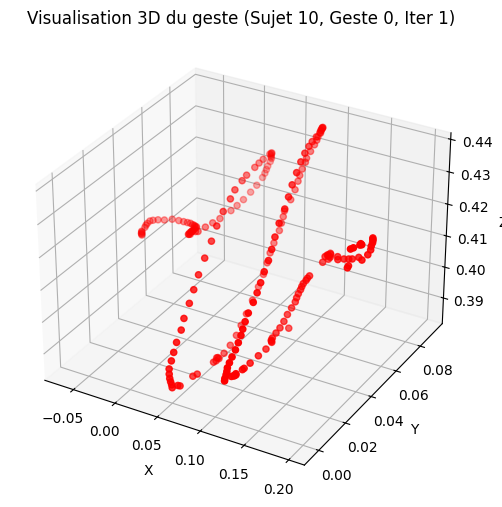


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


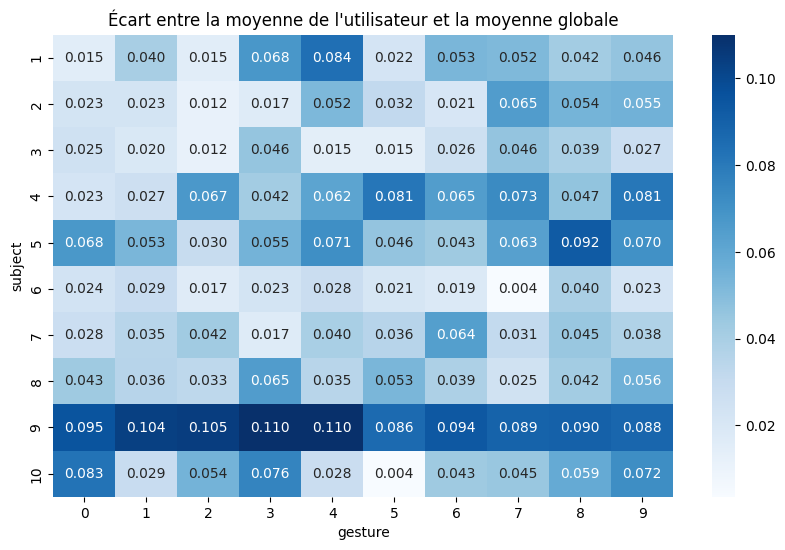

Standardisation...


/tmp/ipykernel_1424/1883634863.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1424/1883634863.py", line 166, in <cell line: 0>
    testmodel(df100, loop_range=10, k=3)
  File "/tmp/ipykernel_1424/1883634863.py", line 155, in testmodel
    y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1424/1883634863.py", line 137, in knn_dtw_predict
    distances.append((gesture, dtw_dist(reference_seq, seq)))
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1424/1883634863.py", line 129, in dtw_dist
    cost = eucl_dist(seq1[i-1], seq2[j-1])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1424/1883634863.py", line 122, in eucl_dist
    return np.sqrt(np.

TypeError: object of type 'NoneType' has no len()

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)

# lstm 256 64 16 final

 Décompression terminée !
--- Début du Chargement du Dossier : /content/temp_data/DOMAIN3_CSVcorrig├й ---


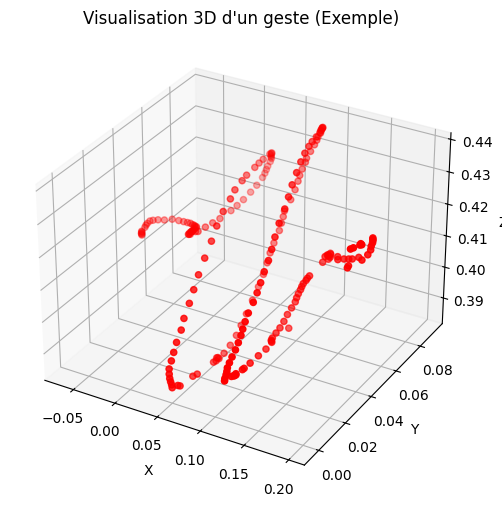


--- Durée moyenne des gestes (s) ---
gesture
0    5165.34
1    3515.14
2    2840.24
3    3804.66
4    4284.83
5    3127.40
6    3925.53
7    1784.65
8    2422.23
9    1990.89
Name: duration, dtype: float64


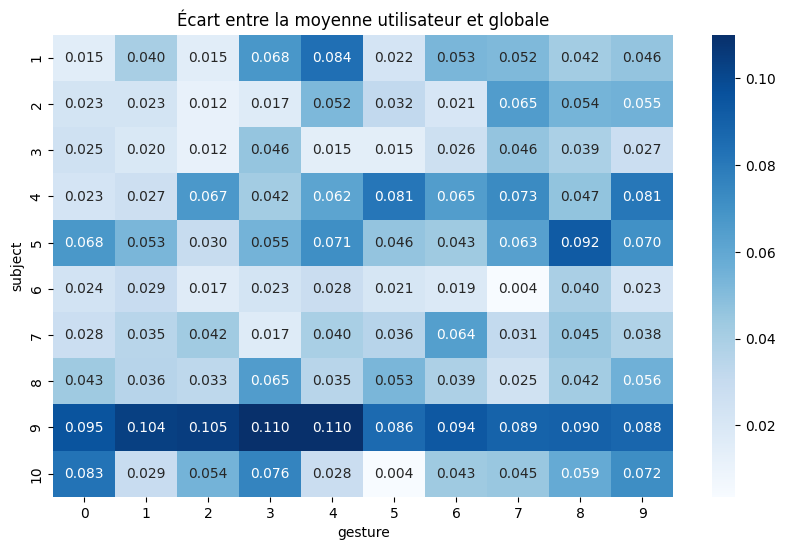


Standardisation en cours...


/tmp/ipykernel_13358/3273130916.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur fixe (100 frames)...

--- Entraînement : Sujet 1 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 1 : 100.00%

--- Entraînement : Sujet 2 en TEST ---


...

Précision pour le sujet 8 : 100.00%

--- Entraînement : Sujet 9 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 9 : 100.00%

--- Entraînement : Sujet 10 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 10 : 100.00%

 PRÉCISION GLOBALE LSTM : 95.10%


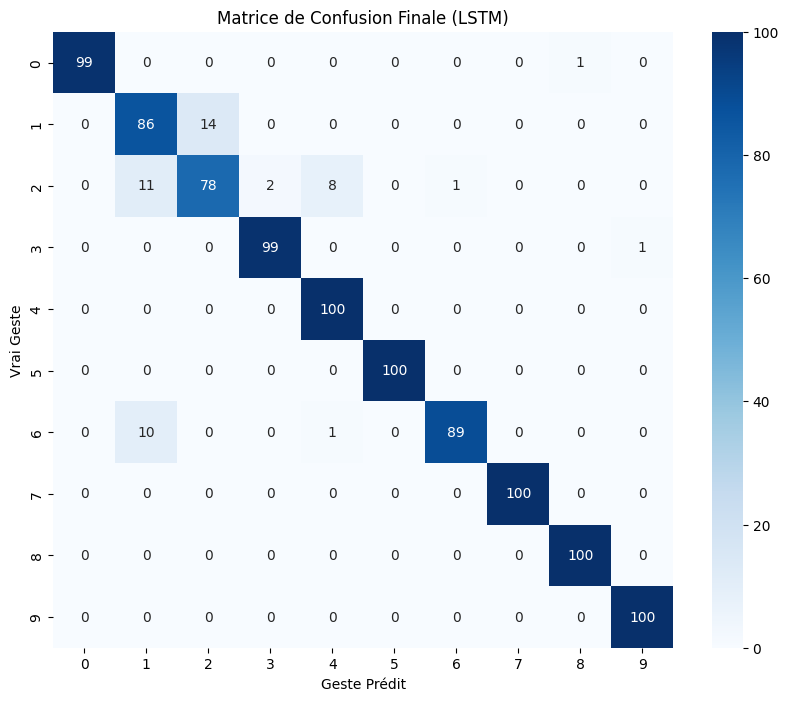

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns
from tensorflow.keras import models, layers

# --- 1. PRÉPARATION DES FICHIERS (GOOGLE COLAB) ---
# Assure-toi d'avoir uploadé le fichier 'DOMAIN3_CSVcorrigé.zip' dans ton espace Colab
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On cherche le dossier qui contient les fichiers (parfois le zip crée un sous-dossier)
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError("Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement du Dossier : {DOMAIN_FOLDER} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant les lignes d'en-tête inutiles
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier trouvé. Vérifiez le nom du ZIP ou la structure des dossiers.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. ANALYSE EXPLORATOIRE & VISUALISATION ---

# A. Visualisation 3D d'un geste (Sujet 10, Geste 0, Iter 1)
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D d'un geste (Exemple)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# B. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter', 'subject'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# C. Heatmap des écarts
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne utilisateur et globale")
plt.show()

# --- 5. PRÉ-TRAITEMENT (STANDARDISATION & RESAMPLING) ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur fixe (100 frames)...")
df100 = resample_gesture(df)

# --- 6. ARCHITECTURE DU MODÈLE LSTM ---

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 7. ÉVALUATION USER-INDEPENDENT (Leave-One-Subject-Out) ---

def test_lstm_user_independent(df_data, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())
    num_classes = int(df_data['gesture'].max() + 1)

    for subj_out in subjects:
        print(f"\n--- Entraînement : Sujet {subj_out} en TEST ---")

        # Split Train / Test
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for (g, s, it), group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(g)
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        # Création et entraînement
        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Prédiction
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Précision pour le sujet {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    # Résultat Final
    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n PRÉCISION GLOBALE LSTM : {final_acc:.2%}")

    # Matrice de Confusion
    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Matrice de Confusion Finale (LSTM)")
    plt.ylabel('Vrai Geste')
    plt.xlabel('Geste Prédit')
    plt.show()

# Lancement du test final
test_lstm_user_independent(df100)

# transoffinal 256 128 64

--- Début du Chargement du Domaine 3 ---
Standardisation...


/tmp/ipykernel_7434/1027807492.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test subject OUT : 1 ---
Exactitude subject 1 : 97.00%

--- Test subject OUT : 2 ---
Exactitude subject 2 : 94.00%

--- Test subject OUT : 3 ---


Exactitude subject 3 : 98.00%

--- Test subject OUT : 4 ---
Exactitude subject 4 : 99.00%

--- Test subject OUT : 5 ---
Exactitude subject 5 : 92.00%

--- Test subject OUT : 6 ---
Exactitude subject 6 : 100.00%

--- Test subject OUT : 7 ---
Exactitude subject 7 : 95.00%

--- Test subject OUT : 8 ---
Exactitude subject 8 : 100.00%

--- Test subject OUT : 9 ---
Exactitude subject 9 : 100.00%

--- Test subject OUT : 10 ---
Exactitude subject 10 : 99.00%

Exactitude globale Transformer : 97.40%


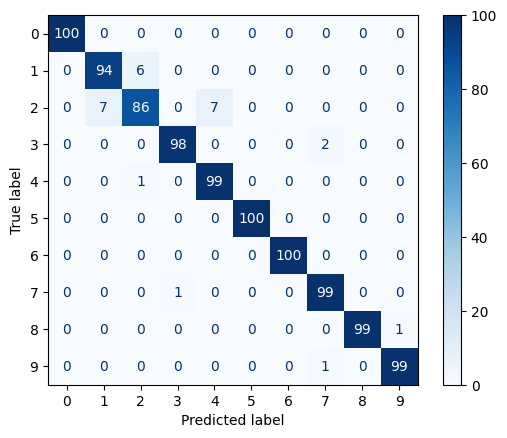

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- 1. CONFIGURATION COLAB ---
zip_path = "/content/DOMAIN3_CSVcorrigé.zip"
extract_path = "/content/temp_data"

if os.path.exists(zip_path):
    if os.path.exists(extract_path): shutil.rmtree(extract_path)
    os.makedirs(extract_path, exist_ok=True)
    # Décompression silencieuse
    !unzip -o -q "{zip_path}" -d "{extract_path}"
else:
    raise FileNotFoundError(f"Fichier {zip_path} introuvable. Upload-le dans Colab.")

# Détection automatique du dossier (évite les erreurs de structure dans le ZIP)
all_dirs = [d for d in glob.glob(os.path.join(extract_path, "**/"), recursive=True)
            if "__MACOSX" not in d and d != extract_path]
DOMAIN_FOLDER = max(all_dirs, key=len) if all_dirs else extract_path
DOMAIN_ID = 3

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant l'entête de 5 lignes
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage et split des données
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier n'a été chargé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# --- 3. PRE-TRAITEMENT ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 4. ARCHITECTURE TRANSFORMER ---
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ÉVALUATION USER-INDEPENDENT ---
def test_transformer_user_independent(df_data, epochs=50, batch_size=64):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for _, group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(group['gesture'].iloc[0])
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        model = create_transformer_model(input_shape=(100, 3), num_classes=10)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        print(f"Exactitude subject {subj_out} : {accuracy_score(y_test, y_pred):.2%}")
        total_true.extend(y_test); total_pred.extend(y_pred)

    print(f"\nExactitude globale Transformer : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues"); plt.show()

test_transformer_user_independent(df100)

# edit distane k-final knnn 3 cluster 20

--- Début du Chargement ---


/tmp/ipykernel_8908/1016699032.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/tmp/ipykernel_8908/1016699032.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision sujet 1 : 99.00%
Test sur sujet sorti : 2
Précision sujet 2 : 92.00%
Test sur sujet sorti : 3
Précision sujet 3 : 99.00%
Test sur sujet sorti : 4
Précision sujet 4 : 95.00%
Test sur sujet sorti : 5
Précision sujet 5 : 89.00%
Test sur sujet sorti : 6
Précision sujet 6 : 84.00%
Test sur sujet sorti : 7
Précision sujet 7 : 90.00%
Test sur sujet sorti : 8
Précision sujet 8 : 99.00%
Test sur sujet sorti : 9
Précision sujet 9 : 98.00%
Test sur sujet sorti : 10
Précision sujet 10 : 94.00%

=== EXACTITUDE GLOBALE : 93.90% ===


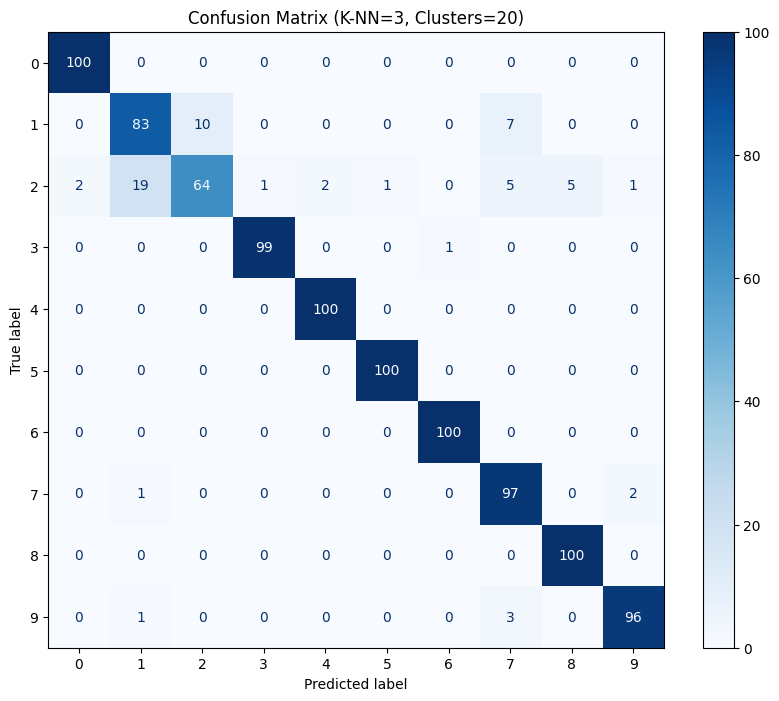

In [2]:
import pandas as pd
import numpy as np
import os
import zipfile
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. CONFIGURATION COLAB & EXTRACTION ---
# Chemin du zip dans Colab (basé sur ton image)
ZIP_PATH = '/content/DOMAIN3_CSVcorrigé.zip'
# Dossier où extraire les données
EXTRACT_FOLDER = '/content/dataset'

if not os.path.exists(EXTRACT_FOLDER):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_FOLDER)
    print("Extraction terminée.")

# On ajuste le chemin pour pointer vers le dossier extrait
# Note : Vérifie si le zip contient un sous-dossier en faisant os.listdir(EXTRACT_FOLDER)
DOMAIN_FOLDER = os.path.join(EXTRACT_FOLDER, "DOMAIN3_CSVcorrigé")

# --- 2. CHARGEMENT DES DONNÉES ---
df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            # Construction du nom de fichier
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture en ignorant les 5 premières lignes comme dans ton code
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Traitement du format spécifique (split des colonnes)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue



# --- 3. PRÉ-TRAITEMENT (Standardisation & Resampling) ---

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])
    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        res_dict = {"gesture": [gesture]*target_len, "subject": [subject]*target_len, "iter": [iteration]*target_len}
        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame(res_dict))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)

# --- 4. ALGORITHMES (Edit Distance & K-NN) ---

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20): # Modifié selon ton image (cluster 20)
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=3): # Modifié selon ton image (knn 3)
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# --- 5. ÉVALUATION (Leave-One-Subject-Out) ---

def testmodel(df_target, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        train_df = df_target[df_target["subject"] != i]
        test_df = df_target[df_target["subject"] == i]
        if test_df.empty: continue

        print(f"Test sur sujet sorti : {i}")
        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10,8))
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", ax=plt.gca())
    plt.title(f"Confusion Matrix (K-NN={k_knn}, Clusters={k_clusters})")
    plt.show()

# Lancement
testmodel(df100)

# dtw m = 30

 Décompression terminée !
---  Début du Chargement (Domain 3) ---
 Standardisation...


/tmp/ipykernel_6187/1735960400.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=30)...

---  Début des 10 tests (Subject-Out) ---
Précision Sujet 1 : 97.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 2 : 98.00%
Précision Sujet 3 : 99.00%


...

Précision Sujet 4 : 100.00%
Précision Sujet 5 : 98.00%
Précision Sujet 6 : 82.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 7 : 91.00%
Précision Sujet 8 : 100.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 98.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 96.30%


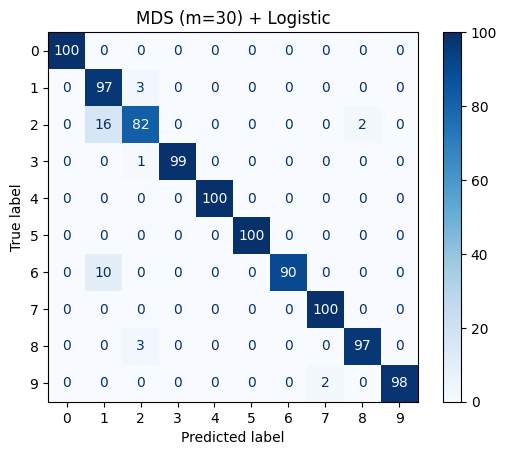

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN3_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 3) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=30):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=30):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"MDS (m={m_dims}) + Logistic")
    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=30)

# dtw m =50

 Décompression terminée !
---  Début du Chargement (Domain 3) ---
 Standardisation...


/tmp/ipykernel_6187/158421782.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=50)...

---  Début des 10 tests (Subject-Out) ---
Précision Sujet 1 : 95.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 2 : 97.00%
Précision Sujet 3 : 99.00%
Précision Sujet 4 : 98.00%


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 7 : 92.00%
Précision Sujet 8 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 9 : 100.00%
Précision Sujet 10 : 100.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 95.90%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


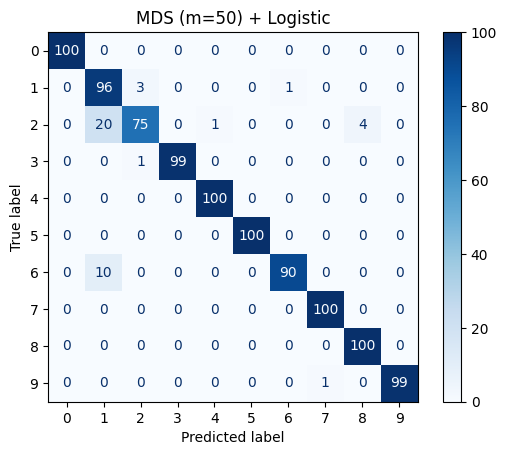

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN3_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 3) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=50):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=50):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"MDS (m={m_dims}) + Logistic")
    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=50)

# dtw m = 20

 Décompression terminée !
---  Début du Chargement (Domain 3) ---
 Standardisation...


/tmp/ipykernel_1679/1260101309.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=20)...

---  Début des 10 tests (Subject-Out) ---
Précision Sujet 1 : 96.00%
Précision Sujet 2 : 98.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 3 : 99.00%
Précision Sujet 4 : 96.00%
Précision Sujet 5 : 95.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 6 : 79.00%
Précision Sujet 7 : 91.00%
Précision Sujet 8 : 99.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 9 : 100.00%
Précision Sujet 10 : 99.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 95.20%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


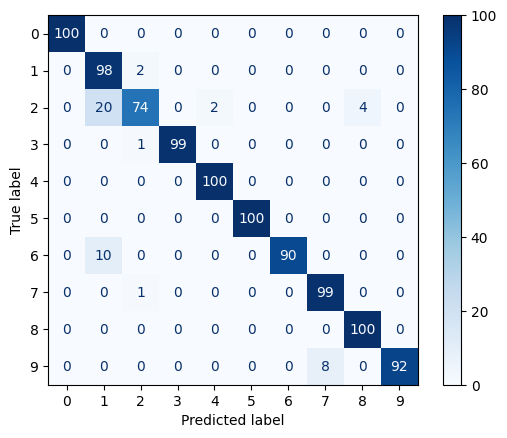

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN3_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 3) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=20):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=20):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")

    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=20)

# dtw m = 40

 Décompression terminée !
---  Début du Chargement (Domain 3) ---
 Standardisation...


/tmp/ipykernel_1679/899544268.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=40)...

---  Début des 10 tests (Subject-Out) ---
Précision Sujet 1 : 96.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 2 : 97.00%
Précision Sujet 3 : 100.00%
Précision Sujet 4 : 98.00%


...

Précision Sujet 5 : 96.00%
Précision Sujet 6 : 83.00%
Précision Sujet 7 : 92.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 8 : 99.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 100.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 96.10%


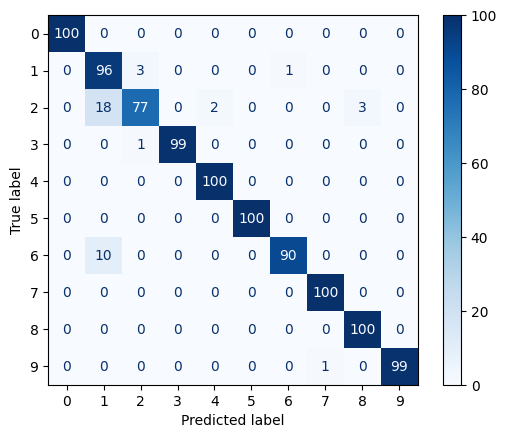

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN3_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 3) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=40):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=40):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")

    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=40)

# dtw m = 35

 Décompression terminée !
---  Début du Chargement (Domain 3) ---
 Standardisation...


/tmp/ipykernel_963/2146919691.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=35)...

---  Début des 10 tests (Subject-Out) ---
Précision Sujet 1 : 97.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 2 : 97.00%
Précision Sujet 3 : 99.00%
Précision Sujet 4 : 98.00%


...

Précision Sujet 5 : 96.00%
Précision Sujet 6 : 86.00%
Précision Sujet 7 : 94.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 8 : 100.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 100.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 96.70%


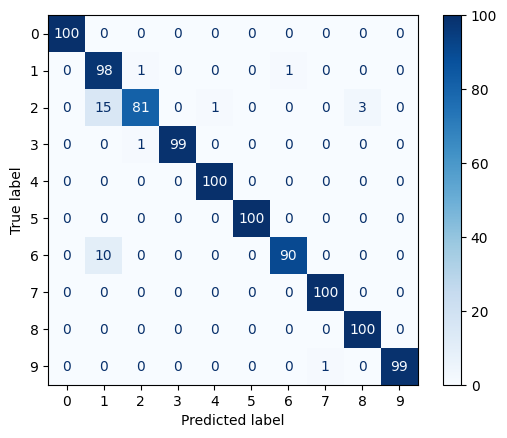

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN3_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 3) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=35):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=35):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")

    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=35)

# dtw m = 33

--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_8908/496001055.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...

--- Début des tests Subject-Out ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 1 : 97.00%
Précision Sujet 2 : 97.00%
Précision Sujet 3 : 98.00%


...

Précision Sujet 4 : 100.00%
Précision Sujet 5 : 96.00%
Précision Sujet 6 : 85.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 7 : 94.00%
Précision Sujet 8 : 100.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 100.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 96.70%


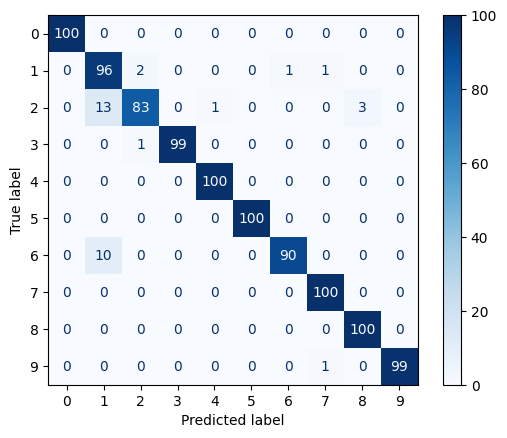

In [4]:
import pandas as pd
import numpy as np
import os
import zipfile
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist

# --- 1. CONFIGURATION COLAB & EXTRACTION ---
ZIP_PATH = '/content/DOMAIN3_CSVcorrigé.zip'
EXTRACT_FOLDER = '/content/dataset'

if not os.path.exists(EXTRACT_FOLDER):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_FOLDER)
    print("Extraction terminée.")

# On ajuste le chemin (souvent le zip contient un dossier du même nom)
DOMAIN_FOLDER = os.path.join(EXTRACT_FOLDER, "DOMAIN3_CSVcorrigé")
if not os.path.exists(DOMAIN_FOLDER):
    DOMAIN_FOLDER = EXTRACT_FOLDER # Si les fichiers sont à la racine de l'extraction

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except (FileNotFoundError, Exception):
                continue

# Fusion efficace de tous les DataFrames
df = pd.concat(df_list, ignore_index=True)


# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW OPTIMISÉ & MDS ---
def dtw_dist(seq1, seq2):
    dists = cdist(seq1, seq2, metric='sqeuclidean')
    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])
    return np.sqrt(dtw_matrix[n, m])

def apply_mds_transform(dist_matrix, m=30):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H
    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)
    return vecs @ np.diag(np.sqrt(vals))

# --- 5. PIPELINE D'ÉVALUATION ---
def run_mds_experiment(df_prep, loop_range=10, m_dims=30):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d


    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n--- Début des tests Subject-Out ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")
        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.show()

# Lancement final
run_mds_experiment(df100, loop_range=10, m_dims=30)

# test afichage

 Décompression terminée !
--- Début du Chargement ---


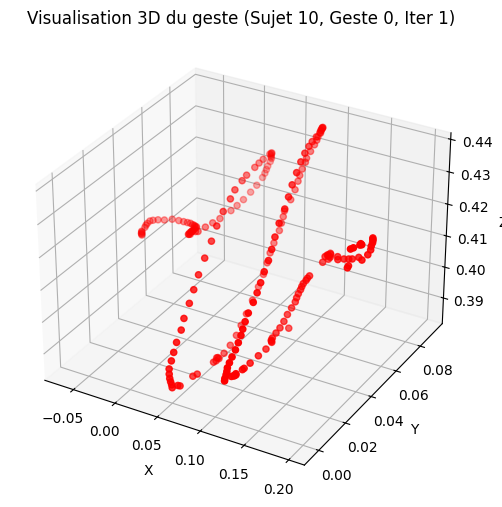


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


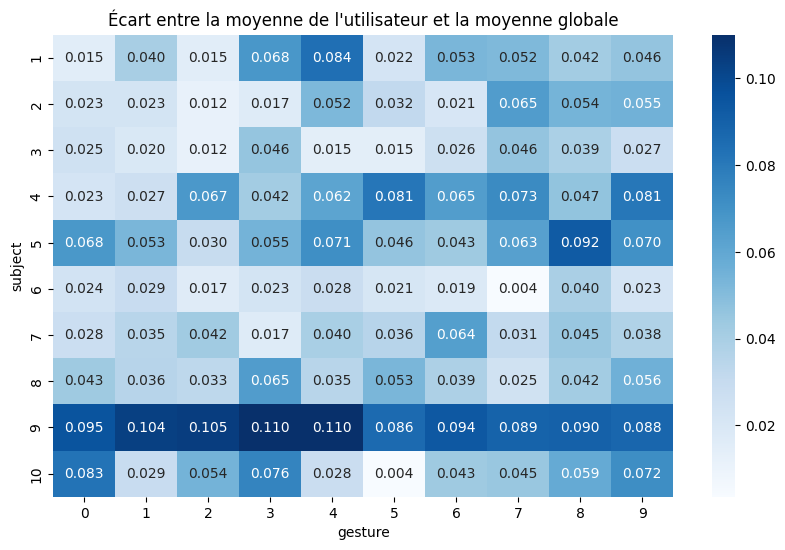

Standardisation...


/tmp/ipykernel_8908/1800600977.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...


KeyboardInterrupt: 

In [8]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)

# affichage suket 6

 Décompression terminée !
--- Début du Chargement ---


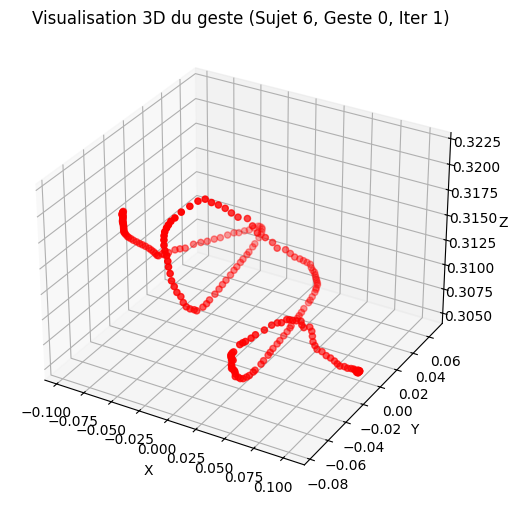


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


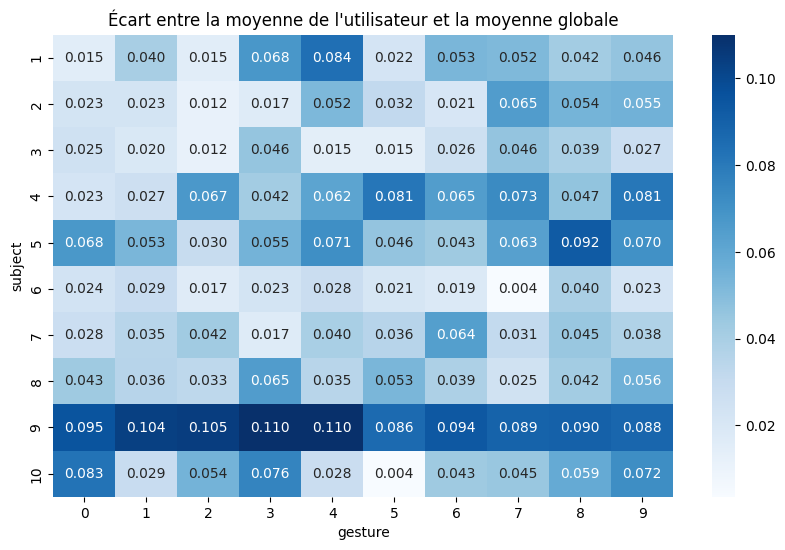

Standardisation...


KeyboardInterrupt: 

In [11]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 6) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 6, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)

# affichage sujet 3

 Décompression terminée !
--- Début du Chargement ---


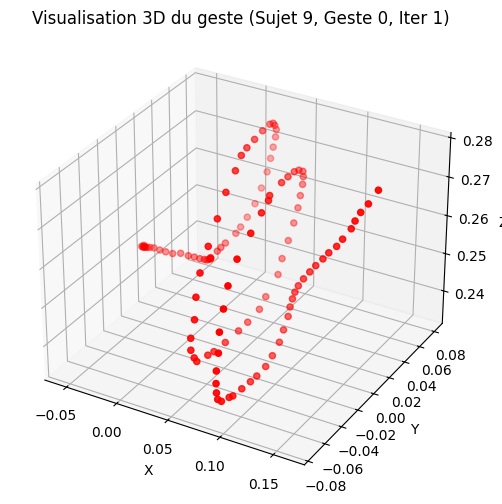


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


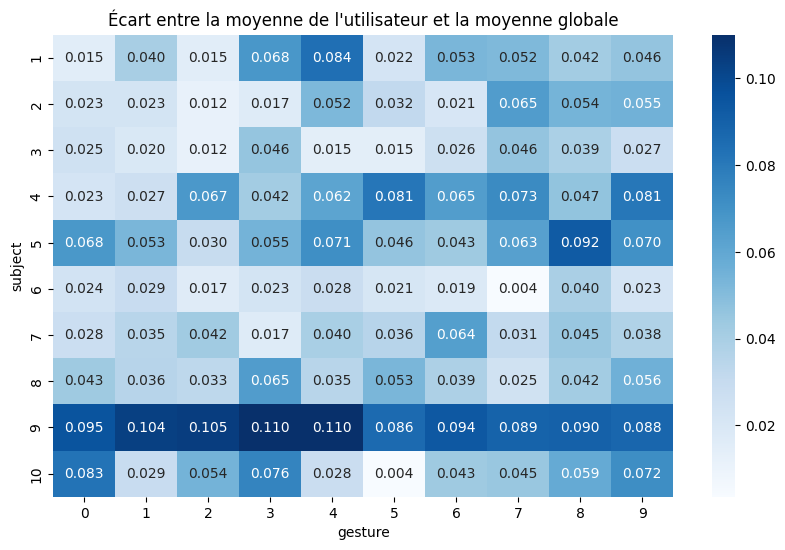

Standardisation...


/tmp/ipykernel_8908/1361924364.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

In [12]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN3_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 9) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 9, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)